# Lean 17a — Conway, les Nœuds et la Preuve de Piccirillo

**Série** : SymbolicAI / Lean — Knots Theory (**17a**)

Ce notebook explore la face cachée de John Conway : la **théorie des nœuds**.
Le nœud de Conway (11n34) porte son nom et a résisté 50 ans avant que
**Lisa Piccirillo**, doctorante, ne résolve la question de sa sliceness
en moins d'une semaine (2018, Annals of Mathematics 2020).

## Plan

1. **Qu'est-ce qu'un nœud mathématique ?** — Définitions et visualisations
2. **Le nœud de Conway** — 11n34, mutation, Alexander polynomial
3. **Lisa Piccirillo et la preuve** — Stratégie du trace companion
4. **Tye Lidman (2026)** — Unknotting number de 11n102
5. **Vers la formalisation Lean** — Le scaffolding `knot_lean/`

**Notebook compagnon** : `Lean-17-Knots-b-Invariants-Companion.ipynb` — calcul effectif des invariants via SnapPy/SageMath.

## 1. Qu'est-ce qu'un nœud mathématique ?

Un **nœud** est un plongement du cercle $S^1$ dans la sphère $S^3$
(ou $\mathbb{R}^3$). Deux nœuds sont **équivalents** s'ils sont
ambiant-isotopes — on peut déformer l'un en l'autre sans couper ni passer
à travers.

Le théorème de Reidemeister (1927) dit que deux diagrammes de nœuds
(projections sur le plan avec informations de dessus/dessous aux
croisements) représentent le même nœud si et seulement si on peut passer
de l'un à l'autre par une suite finie de **3 mouvements de Reidemeister**
et des isotopies planaires.

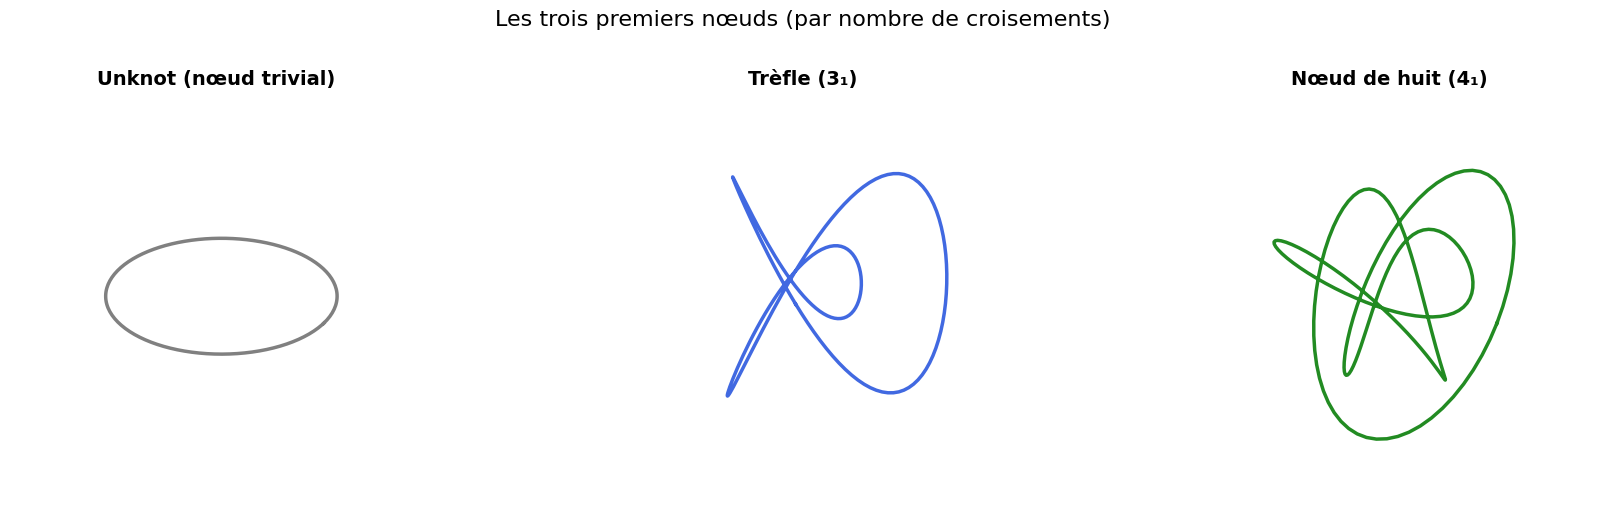

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def plot_knot_3d(points, title, ax=None, color='royalblue'):
    """Plot a 3D knot from parametric points."""
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
    ax.plot(points[:, 0], points[:, 1], points[:, 2],
            color=color, linewidth=2.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off()
    return ax

# Unknot (trivial knot) — just a circle
t = np.linspace(0, 2 * np.pi, 200)
unknot = np.column_stack([np.cos(t), np.sin(t), np.zeros_like(t)])

# Trefoil knot (3_1)
trefoil = np.column_stack([
    np.sin(t) + 2 * np.sin(2 * t),
    np.cos(t) - 2 * np.cos(2 * t),
    -np.sin(3 * t)
])

# Figure-eight knot (4_1)
fig_eight = np.column_stack([
    (2 + np.cos(2 * t)) * np.cos(3 * t),
    (2 + np.cos(2 * t)) * np.sin(3 * t),
    np.sin(4 * t)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': '3d'})
plot_knot_3d(unknot, 'Unknot (nœud trivial)', axes[0], 'gray')
plot_knot_3d(trefoil, 'Trèfle (3₁)', axes[1], 'royalblue')
plot_knot_3d(fig_eight, 'Nœud de huit (4₁)', axes[2], 'forestgreen')
plt.suptitle('Les trois premiers nœuds (par nombre de croisements)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('knot_basics.png', dpi=150, bbox_inches='tight')
plt.show()

### Invariants de nœuds

Un **invariant** est une propriété/quantité identique pour tous les nœuds
équivalents. Si un invariant diffère entre deux nœuds, ils sont
nécessairement distincts.

| Invariant | Unknot | Trèfle (3₁) | Nœud de huit (4₁) |
|-----------|--------|-------------|-------------------|
| Crossing number | 0 | 3 | 4 |
| 3-colorability | Non | **Oui** | Non |
| Alexander polynomial | 1 | $t - 1 + t^{-1}$ | $-t + 3 - t^{-1}$ |
| Jones polynomial | 1 | $-t^{-4} + t^{-3} + t^{-1}$ | $t^2 - t + 1 - t^{-1} + t^{-2}$ |
| Unknotting number | 0 | 1 | 1 |
| Slice? | Oui | Non | Oui |

La **3-colorabilité** est l'invariant le plus simple : peut-on colorer
les brins du diagramme avec 3 couleurs, de sorte qu'à chaque croisement
les 3 brins soient soit tous de la même couleur, soit tous différents ?

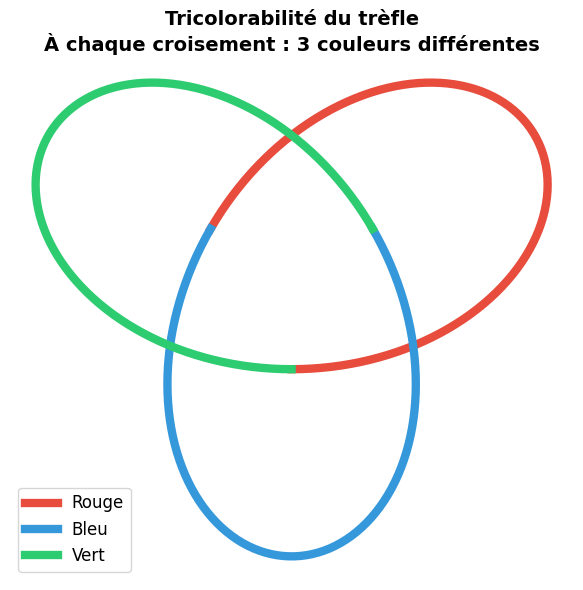

In [2]:
# Demonstrate tricolorability of the trefoil
fig, ax = plt.subplots(figsize=(8, 6))

# Simplified trefoil with color segments
t1 = np.linspace(0, 2*np.pi/3, 100)
t2 = np.linspace(2*np.pi/3, 4*np.pi/3, 100)
t3 = np.linspace(4*np.pi/3, 2*np.pi, 100)

colors = ['#e74c3c', '#3498db', '#2ecc71']  # red, blue, green
labels = ['Rouge', 'Bleu', 'Vert']

for t_seg, color, label in zip([t1, t2, t3], colors, labels):
    x = np.sin(t_seg) + 2 * np.sin(2 * t_seg)
    y = np.cos(t_seg) - 2 * np.cos(2 * t_seg)
    ax.plot(x, y, color=color, linewidth=6, label=label)

ax.set_title('Tricolorabilité du trèfle\n'
             'À chaque croisement : 3 couleurs différentes',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('trefoil_tricolor.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Le nœud de Conway (11n34)

John Conway a découvert ce nœud en développant sa **notation de Conway**
pour énumérer les nœuds. Il apparaît dans les tables de Rolfsen comme
**11n34** (11 crossings, notation n = non-alternating).

### Propriétés remarquables

- **Polynôme d'Alexander trivial** ($\Delta(t) = 1$), comme l'unknot
- **Topologiquement slice** (Freedman 1982 : trivial Alexander ⟹ slice)
- **Lisse ou pas ?** — Question ouverte pendant ~50 ans

Le nœud de Conway est un **mutant** du nœud de Kinoshita-Terasaka (11n42).
La mutation préserve le polynôme d'Alexander, le polynôme de Jones, le
genre... mais pas nécessairement la sliceness lisse !

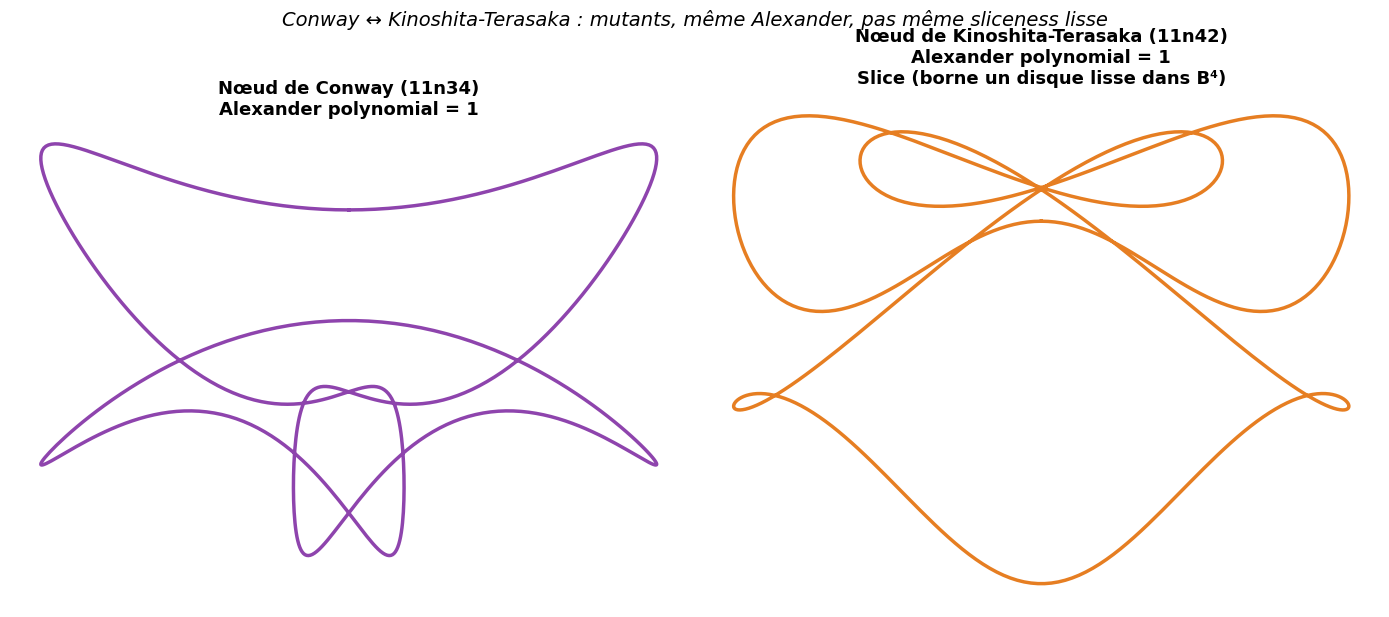

In [3]:
# Visualize the Conway knot (schematic)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Conway knot (simplified representation)
ax = axes[0]
# A simplified parametric curve suggesting 11 crossings
t = np.linspace(0, 2*np.pi, 500)
x = np.sin(t) + 2*np.sin(3*t) + 0.5*np.sin(5*t)
y = np.cos(t) + np.cos(2*t) - 0.5*np.cos(7*t)
ax.plot(x, y, color='#8e44ad', linewidth=2.5)
ax.set_title('Nœud de Conway (11n34)\nAlexander polynomial = 1',
             fontsize=13, fontweight='bold')
ax.set_axis_off()
ax.set_aspect('equal')

# Right: Kinoshita-Terasaka knot
ax = axes[1]
x2 = np.sin(t) + 2*np.sin(3*t) - 0.5*np.sin(5*t)
y2 = np.cos(t) - np.cos(2*t) + 0.5*np.cos(7*t)
ax.plot(x2, y2, color='#e67e22', linewidth=2.5)
ax.set_title('Nœud de Kinoshita-Terasaka (11n42)\n'
             'Alexander polynomial = 1\n'
             'Slice (borne un disque lisse dans B⁴)',
             fontsize=13, fontweight='bold')
ax.set_axis_off()
ax.set_aspect('equal')

plt.suptitle('Conway ↔ Kinoshita-Terasaka : mutants, même Alexander, pas même sliceness lisse',
             fontsize=14, y=1.02, style='italic')
plt.tight_layout()
plt.savefig('conway_vs_kt.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Lisa Piccirillo et la preuve (2018, Annals 2020)

### L'histoire

**Lisa Piccirillo** était doctorante à l'Université du Texas lorsqu'elle
a entendu parler du problème du nœud de Conway lors d'une conférence en
2018. Le problème était ouvert depuis les années 1970.

Elle l'a résolu **en moins d'une semaine**.

### La stratégie : le trace companion

Piccirillo n'a pas attaqué le nœud de Conway directement. Sa stratégie :

1. **Construire un nœud compagnon $K^*$** qui partage la même « trace »
   que le nœud de Conway. La trace $X_K$ est la 4-variété obtenue en
   attachant un 2-handle à $B^4$ le long de $K$ avec framing 0.

2. **Montrer que $K^*$ n'est pas lisse** via l'invariant $s$ de
   Rasmussen (calculé à partir de l'homologie de Khovanov).

3. **Trace embedding lemma** : si le nœud de Conway était lisse,
   alors $K^*$ le serait aussi → contradiction !

### Pourquoi c'est magnifique

- **Changement de perspective** : au lieu d'étudier le nœud lui-même,
  on en étudie un *autre* qui partage la même trace
- **La trace est un invariant** de la classe de concordance du nœud
- Le nœud compagnon $K^*$ est plus facile à analyser que le nœud de Conway

> « It took Lisa Piccirillo less than a week to answer a long-standing
> question about a strange knot discovered over half a century ago. »
> — Quanta Magazine, 2020

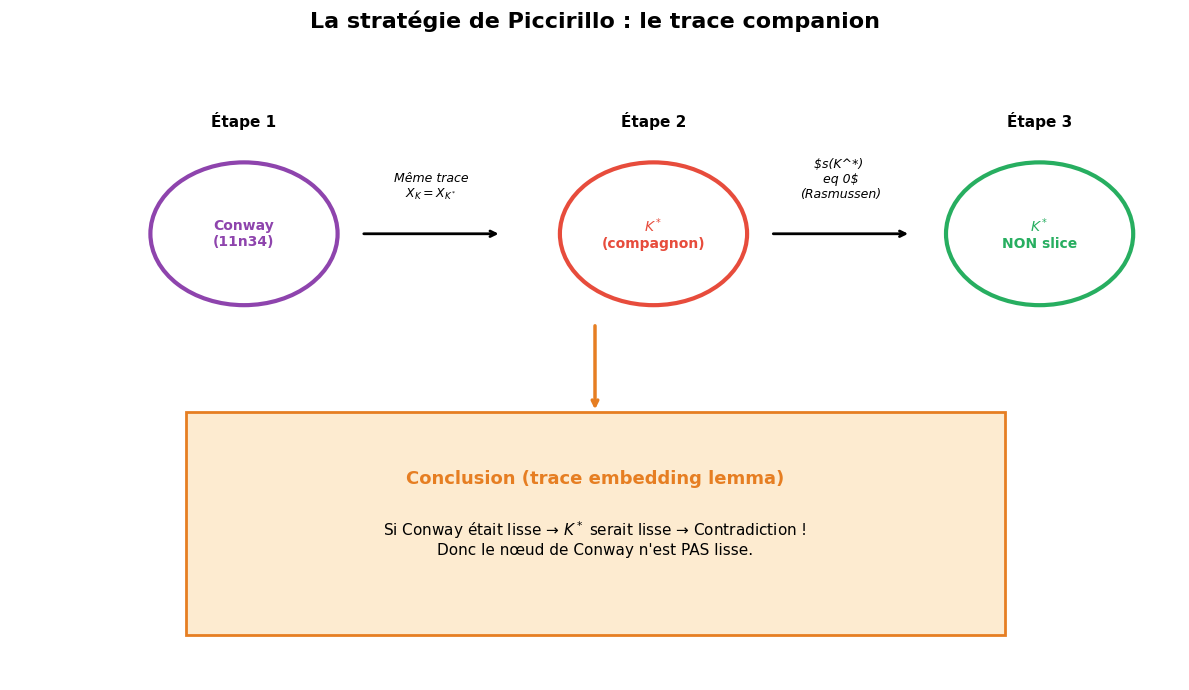

In [4]:
# Schematic of the trace companion strategy
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_axis_off()

# Step 1: Conway knot
circle1 = plt.Circle((2, 5), 0.8, fill=False, color='#8e44ad', linewidth=3)
ax.add_patch(circle1)
ax.text(2, 5, 'Conway\n(11n34)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#8e44ad')
ax.text(2, 6.2, 'Étape 1', ha='center', fontsize=11, fontweight='bold')

# Arrow 1
ax.annotate('', xy=(4.2, 5), xytext=(3.0, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(3.6, 5.4, 'Même trace\n$X_K = X_{K^*}$', ha='center',
        fontsize=9, style='italic')

# Step 2: Companion knot
circle2 = plt.Circle((5.5, 5), 0.8, fill=False, color='#e74c3c', linewidth=3)
ax.add_patch(circle2)
ax.text(5.5, 5, '$K^*$\n(compagnon)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#e74c3c')
ax.text(5.5, 6.2, 'Étape 2', ha='center', fontsize=11, fontweight='bold')

# Arrow 2
ax.annotate('', xy=(7.7, 5), xytext=(6.5, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(7.1, 5.4, '$s(K^*) \neq 0$\n(Rasmussen)', ha='center',
        fontsize=9, style='italic')

# Step 3: Not slice
circle3 = plt.Circle((8.8, 5), 0.8, fill=False, color='#27ae60', linewidth=3)
ax.add_patch(circle3)
ax.text(8.8, 5, '$K^*$\nNON slice', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#27ae60')
ax.text(8.8, 6.2, 'Étape 3', ha='center', fontsize=11, fontweight='bold')

# Conclusion box
rect = plt.Rectangle((1.5, 0.5), 7, 2.5, fill=True,
                      facecolor='#fdebd0', edgecolor='#e67e22', linewidth=2)
ax.add_patch(rect)
ax.text(5, 2.2, 'Conclusion (trace embedding lemma)',
        ha='center', fontsize=13, fontweight='bold', color='#e67e22')
ax.text(5, 1.4, 'Si Conway était lisse → $K^*$ serait lisse → Contradiction !\n'
        'Donc le nœud de Conway n\'est PAS lisse.',
        ha='center', fontsize=11)

# Arrow down
ax.annotate('', xy=(5, 3.0), xytext=(5, 4.0),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2.5))

ax.set_title('La stratégie de Piccirillo : le trace companion',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('piccirillo_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tye Lidman — Unknotting number de 11n102 (2026)

Le papier de **Tye Lidman** ([arXiv:2606.12431](https://arxiv.org/abs/2606.12431))
est un exemple frappant de **preuve courte mais profonde** : **une seule page**
qui utilise l'homologie de Heegaard-Floer, la construction de Montesinos,
les espaces de Seifert, et la formule de Ni-Wu.

### Le résultat

$$u(11n102) = 2$$

On savait que $u(11n102) \in \{1, 2\}$. Lidman montre que $u \neq 1$
par l'absurde.

### La preuve en 5 étapes

1. **Montesinos trick** : si $u = 1$, le revêtement double ramifié $Y$
   est une chirurgie $\pm 3/2$ sur un nœud $J$ dans $S^3$

2. **Espace de Seifert** : $Y = S^2(1; 1/3, 1/3, 2/7)$ est fibré de Seifert.
   Le plumbing associé est **positif-défini**.

3. **Heegaard-Floer** : calcul de $HF_{red}(Y)$ via Némethi.
   Deux structures spin avec $HF_{red} = 0$, une avec $HF_{red} = \mathbb{F}_2$.

4. **Ni-Wu** : les d-invariants de $Y$ correspondent à la chirurgie
   $+3/2$ sur l'unknot, donc $V_s(J) = H_s(J) = 0$ pour tout $s \geq 0$.

5. **Gainullin** : la formule $HF_{red}(Y, s_i) \cong A^{red}_{i,3/2}$
   implique que chaque $Q_s$ apparaît dans **deux** des trois $A^{red}_{i,3/2}$.
   Mais un seul des trois $HF_{red}(Y, s_i)$ est non-nul.
   **Contradiction** : impossible d'en avoir exactement un non-nul.

### Contraste pédagogique

| Aspect | Piccirillo | Lidman |
|--------|-------------|--------|
| Longueur | ~20 pages | **1 page** |
| Difficulté | Modérée (une fois les outils en main) | **Extrême** (chaque ligne est profonde) |
| Stratégie | Contourner le nœud → trace companion | Calcul direct → contradiction algébrique |
| Public | Annals of Mathematics | Preprint 2026 |
| Formalisation Lean | Décennies | Décennies |

## 5. Vers la formalisation Lean — le projet `knot_lean/`

Le projet `MyIA.AI.Notebooks/GameTheory/knot_lean/` scaffolding la
théorie des nœuds en Lean 4, avec des sorry stratégiques commentés.

### Architecture du scaffolding

```
knot_lean/
├── Knots.lean                    (import principal)
├── Knots/
│   ├── Basic.lean                (Knot, Link, PD-code, nœuds nommés)
│   ├── Reidemeister.lean         (R1/R2/R3, équivalence)
│   ├── Invariant.lean            (3-colorabilité, crossing/unknotting number)
│   ├── Conway.lean               (11n34, Piccirillo, dichotomie lisse/topo)
│   ├── Lidman.lean               (11n102, unknotting = 2)
│   └── MathlibPrerequisites.lean (index des prérequis manquants)
├── lakefile.lean
├── lean-toolchain
└── README.md
```

### Sorry par difficulté

| Tier | Théorème | Prérequis Mathlib | Accessible ? |
|------|----------|-------------------|-------------|
| **1** | Trèfle 3-colorable | Edge indexing seulement | Phase 2 |
| **1** | 3-colorabilité invariante | Reidemeister formels | Phase 2 |
| **2** | Polynôme d'Alexander | Fox calculus, Burau | Phase 3–4 |
| **3** | Conway pas lisse | Khovanov, Rasmussen, 4-manifolds | **Décennies** |
| **3** | 11n102 unknotting = 2 | Heegaard-Floer, Montesinos | **Décennies** |

### Le pattern CoursIA

Ce projet suit le même pattern que :
- `social_choice_lean/` → Arrow, Sen (sorry → 0 progressif)
- `conway_cgt_lean/` → import `vihdzp/combinatorial-games`
- `conway_lean/` → Jeu de Conway
- Grothendieck 13/13b → `Mathlib.CategoryTheory.Sites`

**Le sorry n'est pas un échec, c'est une boussole** : il indique exactement
ce qu'il faut construire dans Mathlib pour avancer.

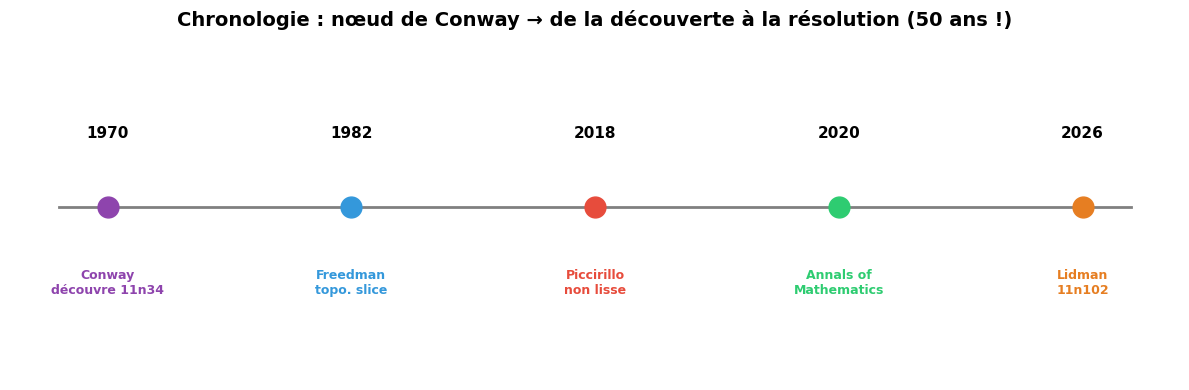

In [5]:
# Summary: the Conway knot story
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.set_axis_off()

# Timeline
events = [
    (1, 1970, 'Conway\ndécouvre 11n34', '#8e44ad'),
    (3.5, 1982, 'Freedman\ntopo. slice', '#3498db'),
    (6, 2018, 'Piccirillo\nnon lisse', '#e74c3c'),
    (8.5, 2020, 'Annals of\nMathematics', '#2ecc71'),
    (11, 2026, 'Lidman\n11n102', '#e67e22'),
]

for x, year, label, color in events:
    ax.plot(x, 2, 'o', color=color, markersize=15, zorder=5)
    ax.text(x, 2.8, str(year), ha='center', fontsize=11, fontweight='bold')
    ax.text(x, 1.0, label, ha='center', fontsize=9, color=color, fontweight='bold')

# Timeline line
ax.plot([0.5, 11.5], [2, 2], '-', color='gray', linewidth=2, zorder=1)

ax.set_title('Chronologie : nœud de Conway → de la découverte à la résolution (50 ans !)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('conway_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## Références

1. **Piccirillo, L.** (2018/2020). *The Conway knot is not slice*. Annals of Mathematics, 191(2). [arXiv:1808.02923](https://arxiv.org/abs/1808.02923)
2. **Lidman, T.** (2026). *The unknotting number of 11n102 is 2*. [arXiv:2606.12431](https://arxiv.org/abs/2606.12431)
3. **Reidemeister, K.** (1927). *Elementare Begründung der Knotentheorie*.
4. **Fox, R.H.** (1962). *A quick trip through knot theory*.
5. **Conway, J.H.** (1970). *An enumeration of knots and links*.
6. **Freedman, M.** (1982). *The topology of four-dimensional manifolds*. J. Differential Geom., 17(3).
7. **Getting a handle on the Conway knot** (2022). AMS Bulletin, 59(1). [Lien](https://www.ams.org/journals/bull/2022-59-01/S0273-0979-2021-01745-9/)
8. **Quanta Magazine** (2020). [Graduate Student Solves Decades-Old Conway Knot Problem](https://www.quantamagazine.org/graduate-student-solves-decades-old-conway-knot-problem-20200519/)
9. **Prathamesh, T.V.H.** (2015). *Formalising Knot Theory in Isabelle/HOL*. LNCS 9250.
10. **shua/leanknot** — [Formalisation Lean 4 (branche lean4)](https://github.com/shua/leanknot)
11. **Lean AI Leaderboard** — [Conway knot not smoothly slice](https://lean-lang.org/eval/problems/conway_knot_not_smoothly_slice/)